# Spatial Analysis


**Objectives**
Investigate the following for residential solar and adoption rates: 
1. Hotspots/coldpsots across all solar and battery metrics. 
2. Local indicators across all spatial association (LISA) for solar and battery metrics. 

**Key Results**
- Created folium maps of hotspot and coldspots saved in 'outputs/' at national and state levels.
- Created folium maps of LISA saved in 'outputs/' at national and state levels.


**Methodology**
Spatial Weights Construction:
- For national level statistics, WA, NT states are removed being out of AEMO regulation. TAS removed being disconnected from the mainland. 
- Queen contiguity. 

Residential Spatial Statistics:
- Solar and batter adoption metrics are normalised using log(1+x)-transformation if skewed.
- Hotspots/coldspots are quantified using Getis Ord G. Permutation test used to infer distribution and p-values.
- Spatial indicators tested using Local Moran I. Permutation test used to infer distribution and p-values.
- Folium maps used to display results in html interactive map.

**Data**
- Geospatial data for LGAs obtained from https://digital.atlas.gov.au/datasets/local-government-area-geoscape-administrative-boundaries/explore/. 
- Solar and Battery adoption metrics obtained from outputs of "2_metrics.ipynb". 
- Socioeconomic data queried from SQL database (originally obtained from ABS data). 



In [221]:
import pandas as pd
import geopandas as gpd 

import numpy as np
import matplotlib.pyplot as plt
import folium

from libpysal.weights import W
from libpysal.weights import KNN

import libpysal
from esda.getisord import G_Local
from esda.moran import Moran, Moran_Local


## Import Data

In [222]:
# Import LGA Data
gdf = gpd.read_file(filename="../data/spatial/LGA_2021_SHP.zip")

# For national level - remove WA, NT and TAS (not under AEMO regulation and TAS is disconnected from mainland)
#gdf = gdf[~gdf['STE_NAME21'].isin(['Western Australia','Northern Territory','Tasmania'])].reset_index(drop=True)
# For state level
gdf = gdf[gdf['STE_NAME21']=='New South Wales'].reset_index(drop=True)

# Print missing geometries
lga_missing_geom = gdf[gdf['geometry'].isna()==True]['LGA_NAME21']
print("LGAs with missing geometries:")
print(lga_missing_geom)

# Remove NAs (offshore/non standard addresses)
gdf = gdf.dropna(subset='geometry')


LGAs with missing geometries:
129                   No usual address (NSW)
130    Migratory - Offshore - Shipping (NSW)
Name: LGA_NAME21, dtype: str


In [223]:

# Import Metrics Data
res_df = pd.read_parquet("../data/processed/resmetrics_data.parquet")
#bus_df = pd.read_parquet("../data/processed/busmetrics_data.parquet")

# Clip growth 
res_df['GrowthSolar'] = res_df['GrowthSolar'].clip(0)

# Add geometry 
gdf_sel = gdf[['LGA_CODE21','LGA_NAME21','STE_NAME21','geometry']]
gdf_sel.columns = ['lga','name','state','geometry']


metrics_gdf = gdf_sel.merge(
    right=res_df[res_df['year']==2024],
    how='inner',
    on='lga'
)



In [224]:
# Reproject to GDA94
if metrics_gdf.crs.to_epsg() != 3577:
    metrics_gdf = metrics_gdf.to_crs(3577)

# Calculate Queen base contiguity matrix
w = libpysal.weights.Queen.from_dataframe(metrics_gdf)

metrics_clean_gdf = metrics_gdf.copy()

# Identify and remove islands
while w.islands:
    print(f"Islands found: {metrics_clean_gdf.loc[w.islands, 'name'].tolist()}")
    metrics_clean_gdf = metrics_clean_gdf.drop(index=w.islands).reset_index(drop=True)
    w = libpysal.weights.Queen.from_dataframe(metrics_clean_gdf)
  

print(f"Final LGA count: {len(metrics_clean_gdf)}")
print(f"LGAs removed: {len(metrics_gdf) - len(metrics_clean_gdf)}")

# Transform
w.transform = 'r'
metrics_gdf = metrics_clean_gdf.copy()


/var/folders/hv/06ql3rk924l7p8lskj2gfm740000gn/T/ipykernel_41652/3802519273.py:6: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = libpysal.weights.Queen.from_dataframe(metrics_gdf)


Final LGA count: 129
LGAs removed: 0


## Spatial Test

In [225]:
def spatial_tests(gdf: gpd.GeoDataFrame, weight_matrix: libpysal.weights.weights.W, var:str):
    '''Calculate spatial statistics'''
    
    # Normalise variable if skewed
    data = gdf[var].copy()
    skew = data.skew()
    
    if abs(skew) > 1:
        data = np.log1p(data)
        print(f"{var}: skew={skew:.4f} — log transform applied")
    else:
        print(f"{var}: skew={skew:.4f} — no transform needed")

    # Create dataframe for results 
    result_df = pd.DataFrame(gdf['lga'])
    
    # Global Moran I
    moran = Moran(data, weight_matrix,permutations=999)
    result_df['moran_global'] = moran.I
    result_df['moran_pval'] = moran.p_sim
    
    # Local Moran I
    moran_local = Moran_Local(data,weight_matrix,permutations=999)    
    result_df['moran_local_I'] = moran_local.Is
    result_df['moran_local_pval'] = moran_local.p_sim
    result_df["quad"] = moran_local.q 
        
    # Local Getis-Ord G
    getis = G_Local(data,weight_matrix, star=True,permutations=999) 
    result_df['getis_G'] = getis.Zs
    result_df['getis_pval'] =  getis.p_sim
    
    return result_df



In [226]:
var_list = ['PenSolar','CPDSolar','CPCSolar','GrowthSolar','PenBattery','CPDBattery','CPCBattery','CPCBattery','BSR']
spatial_result = {}

for var in var_list:
    spatial_result[var] = spatial_tests(metrics_gdf,w,var)
    

PenSolar: skew=10.5604 — log transform applied


/Users/hoseawondo/NextCloud/Projects/PortfolioProjects/Energy/.venv/lib/python3.12/site-packages/esda/getisord.py:421: UserWarning: Gi* requested, but (a) weights are already row-standardized, (b) no weights are on the diagonal, and (c) no default value supplied to star. Assuming that the self-weight is equivalent to the maximum weight in the row. To use a different default (like, .5), set `star=.5`, or use libpysal.weights.fill_diagonal() to set the diagonal values of your weights matrix and use `star=None` in Gi_Local.
  w, star = _infer_star_and_structure_w(w, star, transform)


CPDSolar: skew=9.6694 — log transform applied
CPCSolar: skew=0.0844 — no transform needed
GrowthSolar: skew=2.9738 — log transform applied
PenBattery: skew=5.0261 — log transform applied
CPDBattery: skew=5.0893 — log transform applied
CPCBattery: skew=5.1070 — log transform applied
CPCBattery: skew=5.1070 — log transform applied


/Users/hoseawondo/NextCloud/Projects/PortfolioProjects/Energy/.venv/lib/python3.12/site-packages/esda/getisord.py:421: UserWarning: Gi* requested, but (a) weights are already row-standardized, (b) no weights are on the diagonal, and (c) no default value supplied to star. Assuming that the self-weight is equivalent to the maximum weight in the row. To use a different default (like, .5), set `star=.5`, or use libpysal.weights.fill_diagonal() to set the diagonal values of your weights matrix and use `star=None` in Gi_Local.
  w, star = _infer_star_and_structure_w(w, star, transform)
/Users/hoseawondo/NextCloud/Projects/PortfolioProjects/Energy/.venv/lib/python3.12/site-packages/esda/getisord.py:421: UserWarning: Gi* requested, but (a) weights are already row-standardized, (b) no weights are on the diagonal, and (c) no default value supplied to star. Assuming that the self-weight is equivalent to the maximum weight in the row. To use a different default (like, .5), set `star=.5`, or use li

BSR: skew=1.8950 — log transform applied


/Users/hoseawondo/NextCloud/Projects/PortfolioProjects/Energy/.venv/lib/python3.12/site-packages/esda/getisord.py:421: UserWarning: Gi* requested, but (a) weights are already row-standardized, (b) no weights are on the diagonal, and (c) no default value supplied to star. Assuming that the self-weight is equivalent to the maximum weight in the row. To use a different default (like, .5), set `star=.5`, or use libpysal.weights.fill_diagonal() to set the diagonal values of your weights matrix and use `star=None` in Gi_Local.
  w, star = _infer_star_and_structure_w(w, star, transform)


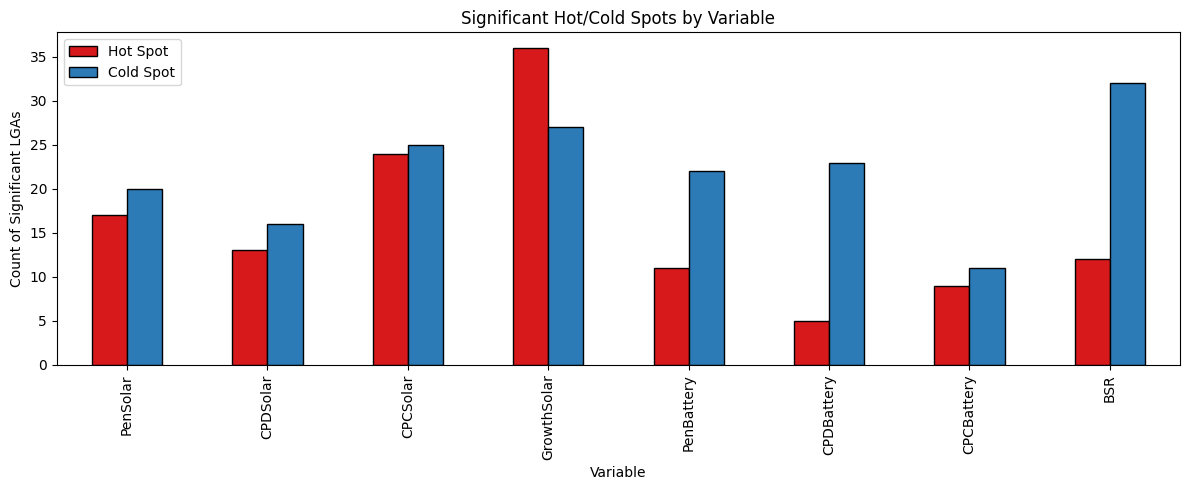

In [227]:
# Bar chart comparing cluster counts across variables

summary = {}
for var in spatial_result.keys():
    sig = spatial_result[var][spatial_result[var]["getis_pval"] < 0.05]
    summary[var] = {
        "Hot Spot":  (sig["getis_G"] > 0).sum(),
        "Cold Spot": (sig["getis_G"] < 0).sum()
    }

df_summary = pd.DataFrame(summary).T
df_summary.plot(kind="bar", figsize=(12, 5), 
                color=["#d7191c", "#2c7bb6"],
                edgecolor="black")
plt.title("Significant Hot/Cold Spots by Variable")
plt.xlabel("Variable")
plt.ylabel("Count of Significant LGAs")
plt.tight_layout()
plt.show()

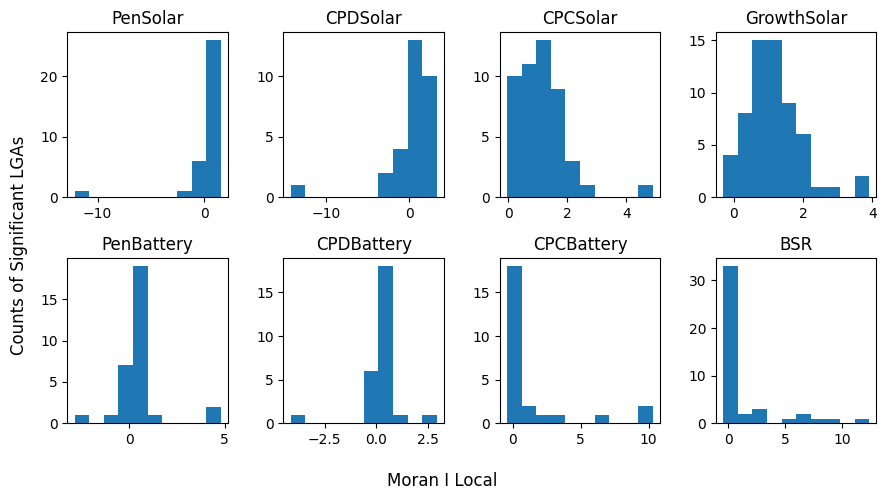

In [228]:
n = len(spatial_result.keys())
n_cols = 4
n_rows = n//n_cols 

fig, ax = plt.subplots(nrows=n_rows, ncols=n_cols,figsize=(9, 5))
for idx, var in enumerate(spatial_result.keys()):
    # Obtain LGAs with significant Local Moran I
    sig_lga = spatial_result[var][['moran_local_I','moran_local_pval']]
    sig_lga = sig_lga[sig_lga['moran_local_pval']<0.05]
    
    # Plot histogram
    axis = ax[idx//n_cols,idx%n_cols]
    axis.hist(x=sig_lga['moran_local_I'])
    axis.set_title(var)

fig.supxlabel('Moran I Local')
fig.supylabel('Counts of Significant LGAs')
plt.tight_layout()

    

PenSolar: n_sig=37, mean_Gs=-0.056099, std_Gs=1.099448
CPDSolar: n_sig=29, mean_Gs=-0.292915, std_Gs=1.182554
CPCSolar: n_sig=49, mean_Gs=-0.073558, std_Gs=1.072516
GrowthSolar: n_sig=63, mean_Gs=0.195708, std_Gs=1.090047
PenBattery: n_sig=33, mean_Gs=0.078879, std_Gs=0.886449
CPDBattery: n_sig=28, mean_Gs=-0.146181, std_Gs=0.850286
CPCBattery: n_sig=20, mean_Gs=0.437694, std_Gs=1.300911
BSR: n_sig=44, mean_Gs=0.056626, std_Gs=1.312943


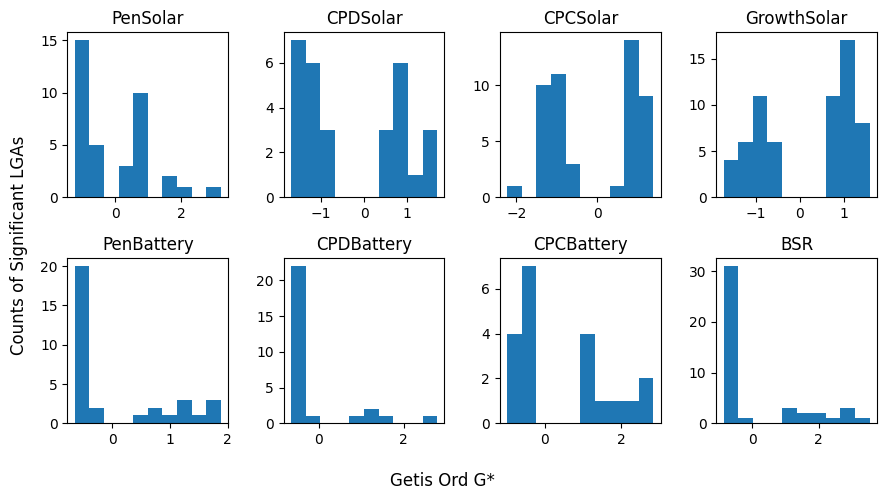

In [229]:
n = len(spatial_result.keys())
n_cols = 4
n_rows = n//n_cols 

fig, ax = plt.subplots(nrows=n_rows, ncols=n_cols,figsize=(9, 5))
for idx, var in enumerate(spatial_result.keys()):
    # Obtain LGAs with significant Local Moran I
    sig = spatial_result[var][['getis_G','getis_pval']]
    sig = sig[sig['getis_pval']<0.05]
    print(f"{var}: n_sig={len(sig)}, mean_Gs={sig['getis_G'].mean():.6f}, std_Gs={sig['getis_G'].std():.6f}")
    
    # Plot histogram
    axis = ax[idx//n_cols,idx%n_cols]
    axis.hist(x=sig['getis_G'])
    axis.set_title(var)

fig.supxlabel('Getis Ord G*')
fig.supylabel('Counts of Significant LGAs')
plt.tight_layout()

## Folium Maps

In [230]:
# --- Functions to classify G and LISA --- #

# Classify G* clusters
def classify_getis(row):
    if row["getis_pval"] < 0.05 and row["getis_G"] >  0:
        return "Hot Spot"
    elif row["getis_pval"] < 0.05 and row["getis_G"] < 0:
        return "Cold Spot"
    elif row["getis_pval"] >= 0.05 and row["getis_G"] >  0:
        return "Hot Spot (Not Significant)"
    else:
        return "Cold Spot (Not Significant)"

# Classify LISA quadrants
quad_map = {1: "HH", 2: "LH", 3: "LL", 4: "HL"}
def classify_lisa(row):
    if row["moran_local_pval"] < 0.05:
        return quad_map.get(row["quad"], "Not Significant")
    return "Not Significant"

# Colour maps
getis_colours = {
    "Hot Spot":        "#d7191c",
    "Cold Spot":       "#2c7bb6",
    "Hot Spot (Not Significant)": "#dc8b8d",
    "Cold Spot (Not Significant)": "#7298b5"
}
lisa_colours = {
    "HH": "#d7191c",
    "LL": "#2c7bb6",
    "HL": "#fdae61",
    "LH": "#abd9e9",
    "Not Significant": "#d3d3d3"
}

# --- Legends for HTML --- #

getis_legend = """
<div style="position:fixed; bottom:30px; left:30px; z-index:1000;
            background:white; padding:10px; border-radius:5px;
            border:1px solid grey; font-size:12px;">
    <b>Getis-Ord G*</b><br>
    <i style="background:#d7191c; width:12px; height:12px; display:inline-block;"></i> Hot Spot<br>
    <i style="background:#2c7bb6; width:12px; height:12px; display:inline-block;"></i> Cold Spot<br>
    <i style="background:#dc8b8d; width:12px; height:12px; display:inline-block;"></i> Hot Spot (Not Significant)<br>
    <i style="background:#7298b5; width:12px; height:12px; display:inline-block;"></i> Cold Spot (Not Significant)
</div>
"""

lisa_legend = """
<div style="position:fixed; bottom:30px; left:30px; z-index:1000;
            background:white; padding:10px; border-radius:5px;
            border:1px solid grey; font-size:12px;">
    <b>Local Moran's I (LISA)</b><br>
    <i style="background:#d7191c; width:12px; height:12px; display:inline-block;"></i> HH — High cluster<br>
    <i style="background:#2c7bb6; width:12px; height:12px; display:inline-block;"></i> LL — Low cluster<br>
    <i style="background:#fdae61; width:12px; height:12px; display:inline-block;"></i> HL — High outlier<br>
    <i style="background:#abd9e9; width:12px; height:12px; display:inline-block;"></i> LH — Low outlier<br>
    <i style="background:#d3d3d3; width:12px; height:12px; display:inline-block;"></i> Not Significant
</div>
"""

# --- Main Map Generating Functions --- #

def make_getis_map(gdf_export, spatial_result, var, output_path):
    
    df      = spatial_result[var].copy()
    gdf_var = gdf_export.merge(df, on="lga", how="left")
    gdf_var["getis_cluster"] = gdf_var.apply(classify_getis, axis=1)
    gdf_var["getis_colour"]  = gdf_var["getis_cluster"].map(getis_colours)

    m = folium.Map(location=[-28.0, 135.0], 
                   zoom_start=4,
                   tiles="CartoDB positron")

    folium.GeoJson(
        gdf_var,
        style_function=lambda f: {
            "fillColor":   f["properties"]["getis_colour"],
            "color":       "black",
            "weight":      0.3,
            "fillOpacity": 0.7
        },
        tooltip=folium.GeoJsonTooltip(
            fields=["lga", "getis_cluster", "getis_G", "getis_pval"],
            aliases=["LGA", "Cluster", "Z-Score", "P-Value"]
        )
    ).add_to(m)

    m.get_root().html.add_child(folium.Element(getis_legend))
    m.save(output_path)
    print(f"Saved: {output_path}")


def make_lisa_map(gdf_export, spatial_result, var, output_path):
    
    df = spatial_result[var].copy()
    gdf_var = gdf_export.merge(df, on="lga", how="left")
    gdf_var["lisa_cluster"] = gdf_var.apply(classify_lisa, axis=1)
    gdf_var["lisa_colour"]  = gdf_var["lisa_cluster"].map(lisa_colours)

    m = folium.Map(location=[-28.0, 135.0], zoom_start=4,
                   tiles="CartoDB positron")

    folium.GeoJson(
        gdf_var,
        style_function=lambda f: {
            "fillColor":   f["properties"]["lisa_colour"],
            "color":       "black",
            "weight":      0.3,
            "fillOpacity": 0.7
        },
        tooltip=folium.GeoJsonTooltip(
            fields=["lga", "lisa_cluster", "moran_local_I", "moran_local_pval"],
            aliases=["LGA", "LISA", "Local I", "P-Value"]
        )
    ).add_to(m)

    m.get_root().html.add_child(folium.Element(lisa_legend))
    m.save(output_path)
    print(f"Saved: {output_path}")



In [231]:
# Reproject to WGS84 for Folium
gdf_export = metrics_gdf.to_crs(epsg=4326).copy()

# Call for each significant variable
for var in var_list:
    make_getis_map(gdf_export, spatial_result, var,
                   f"../outputs/NSW/getis_{var}.html")
    make_lisa_map(gdf_export, spatial_result, var,
                  f"../outputs/NSW/lisa_{var}.html")

Saved: ../outputs/NSW/getis_PenSolar.html
Saved: ../outputs/NSW/lisa_PenSolar.html
Saved: ../outputs/NSW/getis_CPDSolar.html
Saved: ../outputs/NSW/lisa_CPDSolar.html
Saved: ../outputs/NSW/getis_CPCSolar.html
Saved: ../outputs/NSW/lisa_CPCSolar.html
Saved: ../outputs/NSW/getis_GrowthSolar.html
Saved: ../outputs/NSW/lisa_GrowthSolar.html
Saved: ../outputs/NSW/getis_PenBattery.html
Saved: ../outputs/NSW/lisa_PenBattery.html
Saved: ../outputs/NSW/getis_CPDBattery.html
Saved: ../outputs/NSW/lisa_CPDBattery.html
Saved: ../outputs/NSW/getis_CPCBattery.html
Saved: ../outputs/NSW/lisa_CPCBattery.html
Saved: ../outputs/NSW/getis_CPCBattery.html
Saved: ../outputs/NSW/lisa_CPCBattery.html
Saved: ../outputs/NSW/getis_BSR.html
Saved: ../outputs/NSW/lisa_BSR.html
